## Problem 9.3 - Kernelized SVM

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons
from matplotlib.colors import LinearSegmentedColormap
from sklearn import svm
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import zero_one_loss

In [11]:
# truncate the colormap RdPu (I just do that for aesthetic reasons)
truncated_RdPu = LinearSegmentedColormap.from_list('truncated_RdPu', plt.cm.RdPu(np.linspace(0.3, 0.8, 100))) 

In [59]:
X, y = make_moons(n_samples = 200, noise = 0.15, random_state = 42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42)

### (i) Train SVM classifier with different kernels

In [60]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']

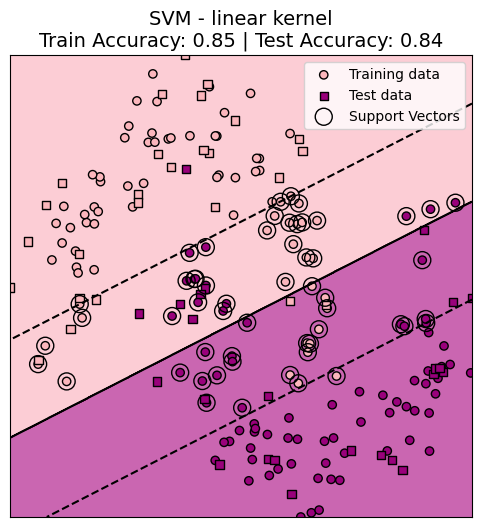

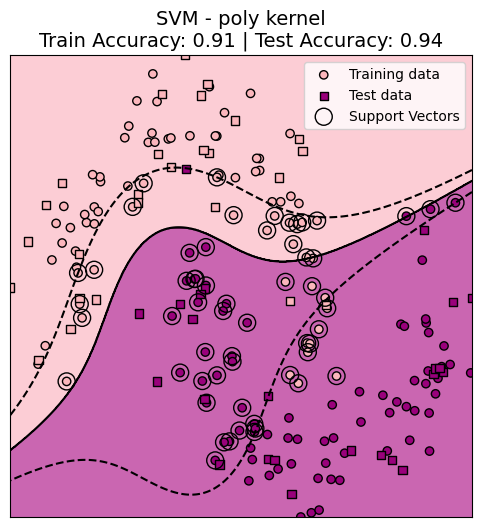

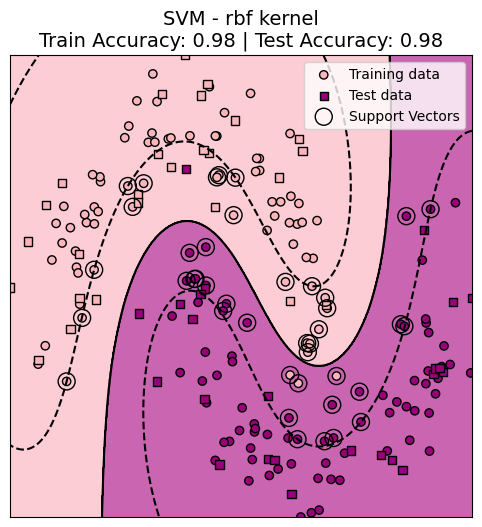

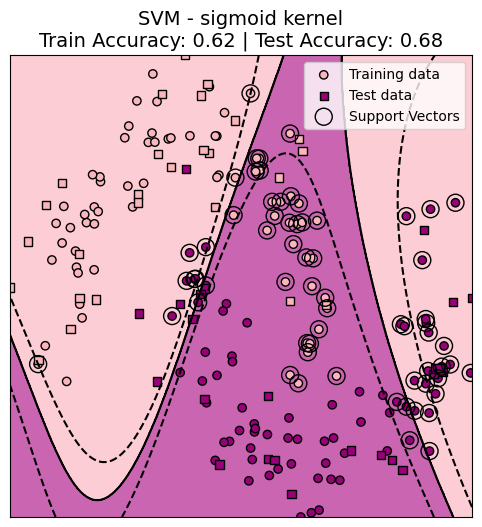

In [61]:
for kernel in kernels:
    svm = SVC(kernel = kernel, degree = 3)
    svm.fit(X_train, y_train)

    svm_train_accuracy = svm.score(X_train, y_train)
    svm_test_accuracy  = svm.score(X_test, y_test)

    fig = plt.figure(figsize = (8, 6))
    ax = fig.add_subplot(111)
    x0, x1 = np.meshgrid(
        np.linspace(X[:,0].min(), X[:,0].max(), 500).reshape(-1, 1),
        np.linspace(X[:,1].min(), X[:,1].max(), 500).reshape(-1, 1)
    )

    x_new = np.c_[x0.ravel(), x1.ravel()]
    y_pred = svm.predict(x_new)
    zz = y_pred.reshape(x0.shape)

    plt.contourf(x0, x1, zz, alpha = 0.6, cmap = truncated_RdPu)
    plt.contour(x0, x1, zz, colors = ['black'], linewidths = [0.4])
    plt.scatter(X_train[:,0], X_train[:,1], c = y_train, edgecolors = 'k', cmap = truncated_RdPu, label = 'Training data')
    plt.scatter(X_test[:,0], X_test[:,1], c = y_test, marker = 's', edgecolors = 'k', cmap = truncated_RdPu, label = 'Test data')
    ax.set_title(
            f"SVM - {kernel} kernel\n"
            f"Train Accuracy: {svm_train_accuracy:.2f} | "
            f"Test Accuracy: {svm_test_accuracy:.2f}",
            fontsize = 14
        )
    
    decision_function = svm.decision_function(x_new).reshape(x0.shape)
    sv = svm.support_vectors_
    plt.scatter(sv[:,0], sv[:,1], s = 150, facecolors = 'none', edgecolors = 'k', label = 'Support Vectors')
    plt.contour(x0, x1, decision_function, levels = [-1, 0, 1], colors = 'black', linestyles = ['--', '-', '--'])

    ax.set_box_aspect(1)
    ax.xaxis.set_tick_params(labelbottom = False)
    ax.yaxis.set_tick_params(labelleft = False)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.legend()

**Kernel comparison:**
- Linear Kernel: moderate performance as it fails to capture the moon shape
- Polnomial Kernel: good performance, polynomial function of degree 3 captures the moon-shaped data better 
- Rbf Kernel: best performance as it captures the moon-shaped data almost perfectly
- Sigmoid Kernel: poor performance, does not create moon shaped decision boundaries at all.

### (ii) Test SVM with rbf-kernel for different (C, γ)

In [62]:
C_vals = [0.1, 1, 1000]
gamma_vals = [0.1, 1, 10]

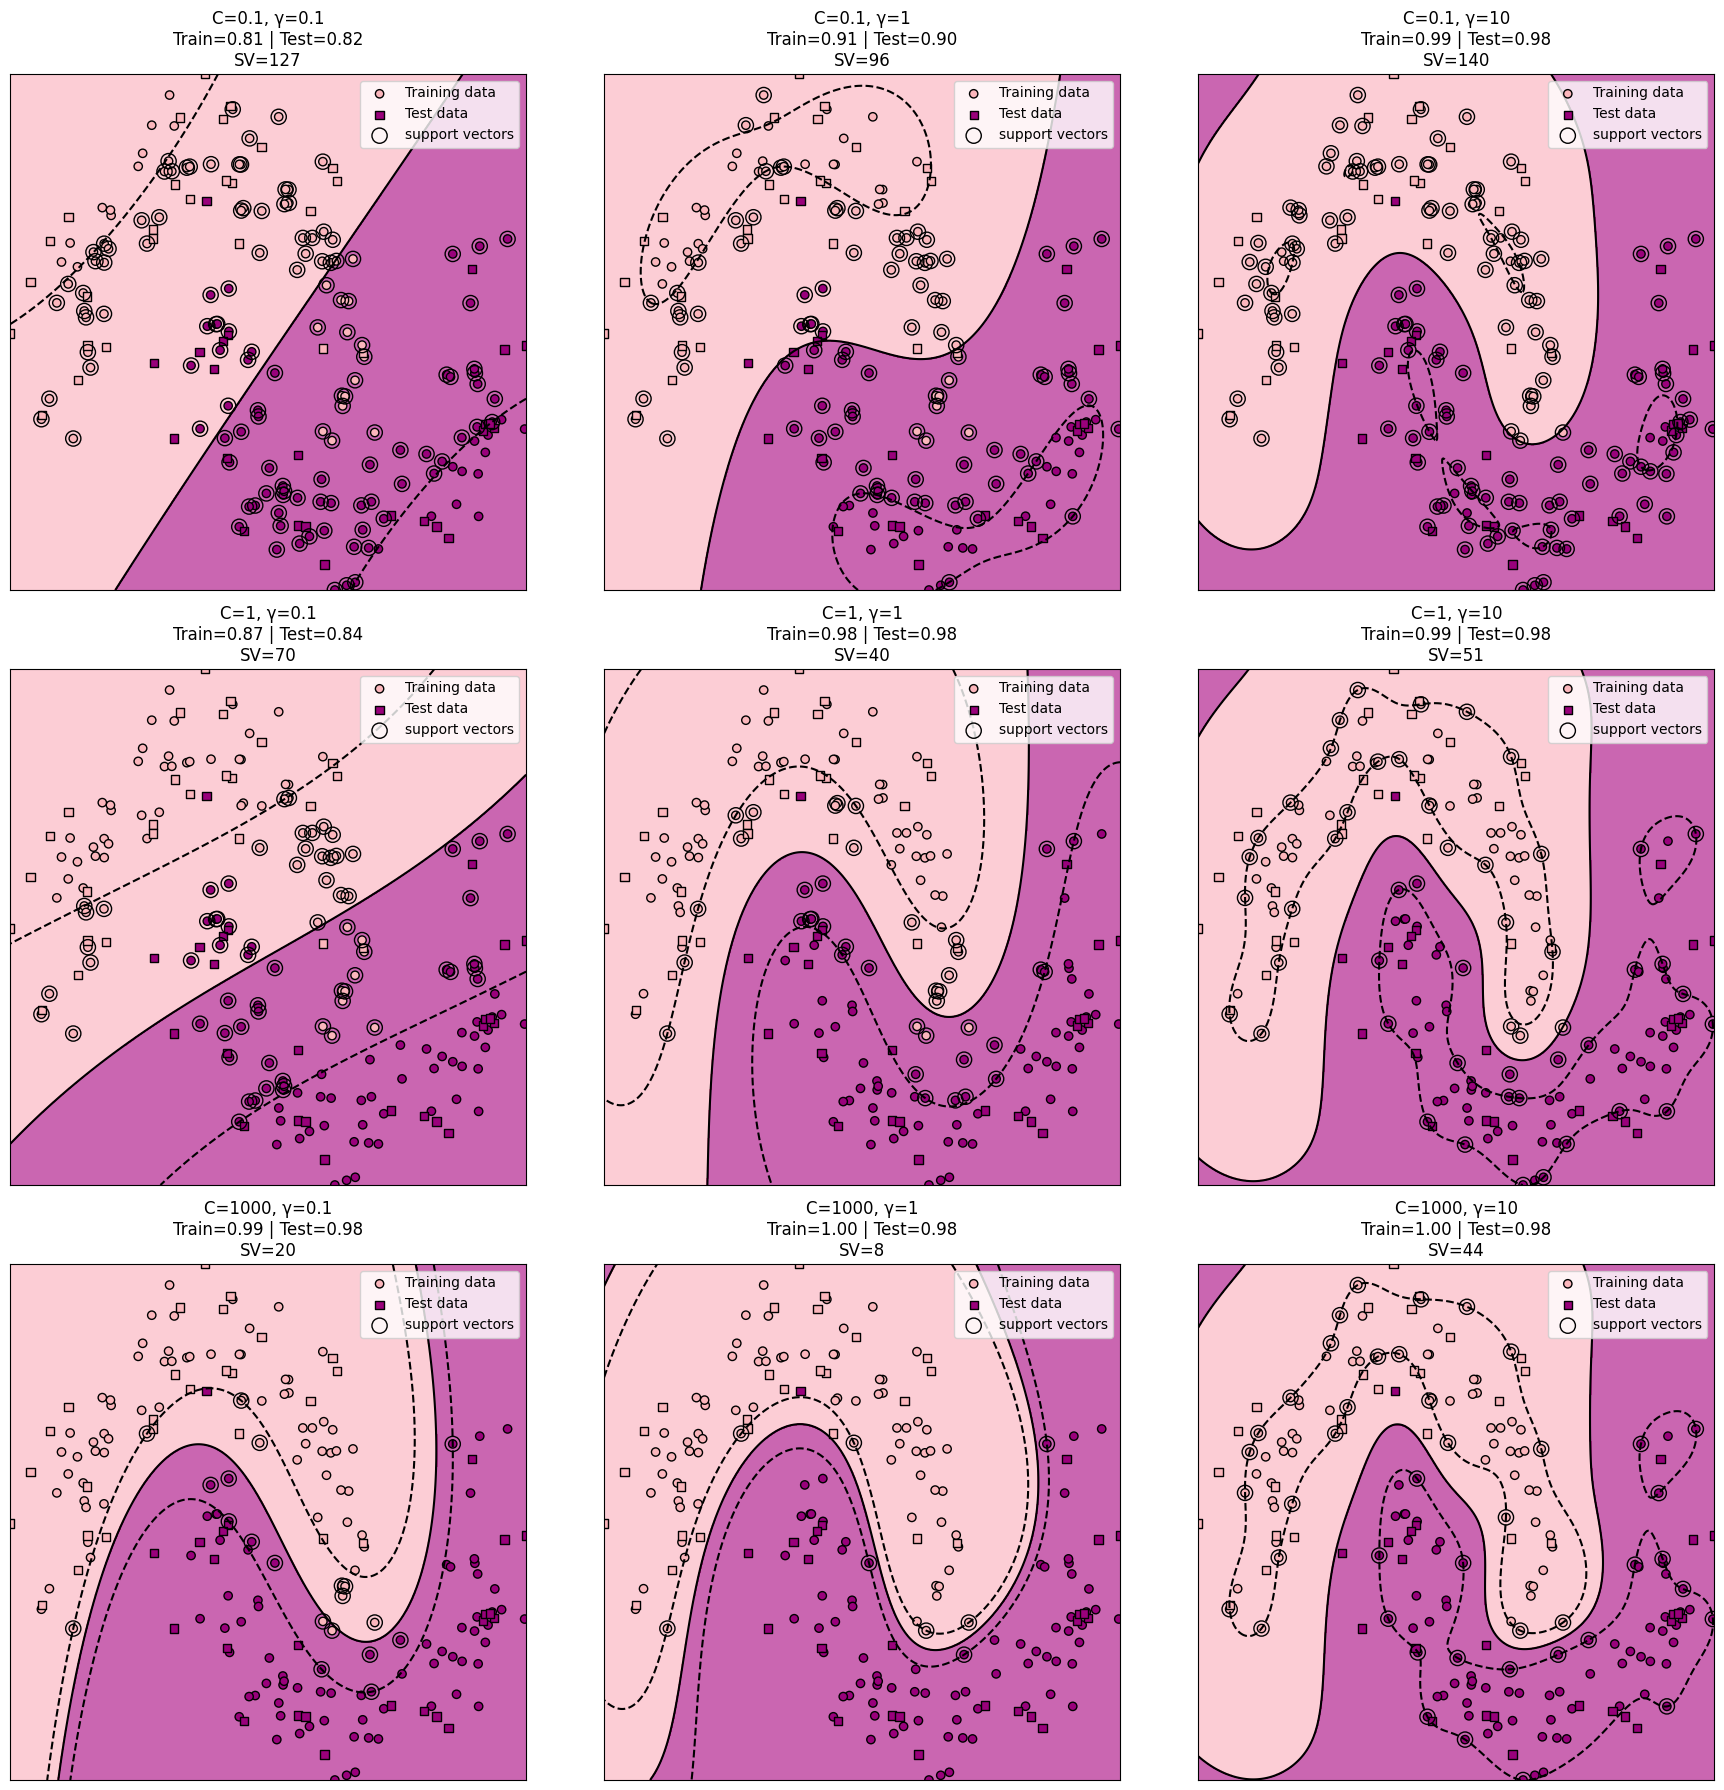

In [63]:
fig, axes = plt.subplots(3, 3, figsize = (18, 18))

for i, C in enumerate(C_vals):
    for j, gamma in enumerate(gamma_vals):

        svm = SVC(kernel = 'rbf', C = C, gamma = gamma, random_state = 42)
        svm.fit(X_train, y_train)

        train_acc = svm.score(X_train, y_train)
        test_acc  = svm.score(X_test, y_test)
        n_sv = len(svm.support_vectors_)

        ax = axes[i, j]

        x0, x1 = np.meshgrid(
            np.linspace(X[:,0].min(), X[:,0].max(), 500).reshape(-1, 1),
            np.linspace(X[:,1].min(), X[:,1].max(), 500).reshape(-1, 1)
        )
        x_new = np.c_[x0.ravel(), x1.ravel()]

        zz = svm.decision_function(x_new).reshape(x0.shape)
        y_pred = svm.predict(x_new).reshape(x0.shape)
        ax.contourf(x0, x1, y_pred, alpha = 0.6, cmap = truncated_RdPu)

        ax.contour(x0, x1, zz, levels = [-1, 0, 1], colors = 'black', linestyles = ['--', '-', '--'])

        ax.scatter(X_train[:,0], X_train[:,1], c = y_train, edgecolors = 'k', cmap = truncated_RdPu, label = 'Training data')
        ax.scatter(X_test[:,0], X_test[:,1], c = y_test, marker = 's', edgecolors = 'k', cmap = truncated_RdPu, label = 'Test data')

        ax.scatter(svm.support_vectors_[:,0], svm.support_vectors_[:,1], s = 120, facecolors = 'none', edgecolors = 'black', label = 'support vectors')

        ax.set_title(
            f"C={C}, γ={gamma}\n"
            f"Train={train_acc:.2f} | Test={test_acc:.2f}\n"
            f"SV={n_sv}",
            fontsize=12
        )

        ax.set_box_aspect(1)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.legend()

plt.tight_layout()
plt.show()

**C-values:**
- controls trade-off between margin width and classification errors
- low C: allows misclassifictaion while maximizing margin width, simpler boundaries, risk of underfitting
- high C: forces correct classification with smaller margin width, complex boundaries, risk of overfitting
- higher C -> fewer support vectors

**gamma-values:**
- constrols the influence a single training points has on the model (i.e. how far the influence reaches)
- low gamma: each point influences a large area so the model is less sensitive to noise -> risk of underfitting
- high gamma: each point influences a small area so the model is very sensitive to nearby points -> risk of overfitting

### (iii) Experiment with gamma

In [64]:
X, y = make_moons(n_samples = 200, noise = 0.3, random_state = 42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42)

In [71]:
gammas = [10, 5, 1, 0.5, 0.1]
C_values = np.logspace(-2, 5, num = 10)

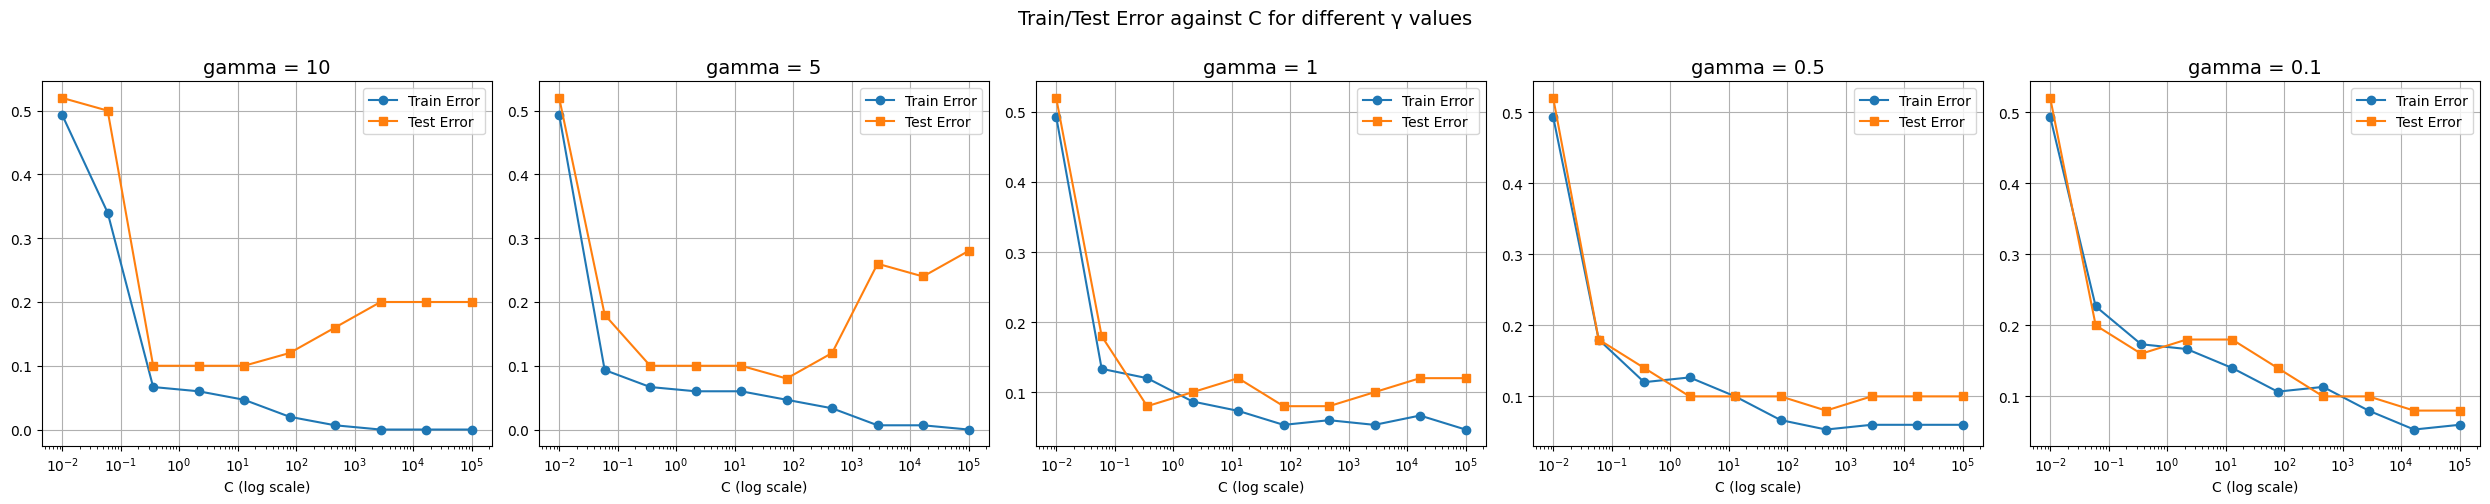

In [79]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
fig.suptitle('Train/Test Error against C for different γ values', fontsize = 14, y = 1)

for idx, gamma in enumerate(gammas):
    train_errors = []
    test_errors = []

    for C in C_values:
        classification = SVC(kernel = 'rbf', gamma = gamma, C = C, random_state = 42)
        classification.fit(X_train, y_train)

        train_err = zero_one_loss(y_train, classification.predict(X_train), normalize = True)
        test_err = zero_one_loss(y_test, classification.predict(X_test), normalize = True)

        train_errors.append(train_err)
        test_errors.append(test_err)

    ax = axes[idx]
    ax.semilogx(C_values, train_errors, marker = 'o', label = 'Train Error')
    ax.semilogx(C_values, test_errors, marker = 's', label = 'Test Error')

    ax.set_title(f"gamma = {gamma}", fontsize = 14)
    ax.set_xlabel("C (log scale)")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

**Observations:**
- The training error is quickly decreasing for each different gamma and with increasing C values. This indicates that the data is fitted a lot better when increasing C.
- For a larger gamma the test error is increasing again, when we also increase C due to overfitting the data.
- For smaller gamma-values the test error DOES decrease with larger C. This indicates that a smaller gamma value with a larger C-value is optimal.